Written by Zoe Krauss, zkrauss@uw.edu

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import obspy
import scipy
import matplotlib
import pandas as pd
from scipy.constants import c
from pyproj import Geod

import mmap
import struct
import os
import msgpack
from pathlib import Path 
import logging 
import datetime 
from math import prod

The Nokia multispan DAS data is stored in binary files that contain data arrays and metadata.

During data writing, a new file was saved everytime a buffer filled up, such that the size of the data arrays varies from file to file depending on the amount of spatial data being collected at a given time. The time listed in the filename is also generally inaccurate due to an artifact in the file naming process. It is important that the timing of the data, the acquisition parameters, and the data shape/size is read from the metadata within the file itself. 

We start by defining some functions to read in the binary data files.

In [2]:
def decoder(obj):
    """
    Custom decoder for Nokia DAS NumPy arrays.
    Reconstructs a NumPy array from the custom dictionary format.
    """
    if '__ndarray__' in obj:
        # Reconstruct the array from its components
        return np.frombuffer(obj['data'], dtype=np.dtype(obj['dtype'])).reshape(obj['shape'])
    return obj

def open_array_from_file(file, 
                             load_data=True, 
                             reshape=True, 
                             stack_axis=-2,
                             closefile=True,
                             slice = np.s_[...], 
                             buffer=None ):
        """
        Read data and metadata from custom binary files

        input: file path as a string

        output: object containing both metadata and data array
        """
    
        magic_var = b'OFDR1MAGIC'
        this_arr = {} 
        f = open(file,'rb')
        f.seek(-len(magic_var),os.SEEK_END)
        magic = f.read(len(magic_var))
        if magic==magic_var:
            
            f.seek(0,os.SEEK_SET)
            front_magic = f.read(len(magic_var))
            if front_magic == magic: 

                version,headerbytes,arrstart = struct.unpack('<BII',f.read(struct.calcsize('<BII'))
                              )
                unpacker = msgpack.Unpacker(raw=False,object_hook=decoder)
                unpacker.feed( f.read(headerbytes) )

                this_arr['array_info'] =unpacker.unpack()
                unpacker.unpack()
                this_arr['chunk_meta'] =unpacker.unpack()
                
                format = '<I'
                f.seek(-(len(magic_var)+struct.calcsize(format)),os.SEEK_END)
                back_bytes, = struct.unpack(format, f.read(struct.calcsize(format)) ) 

                f.seek(-(len(magic_var)+struct.calcsize(format) + back_bytes  ),os.SEEK_END)
                end_msgpack = f.read(back_bytes)

                unpacker = msgpack.Unpacker(raw=False,object_hook=decoder)
                unpacker.feed( end_msgpack )
                this_arr['bytes_written']  = unpacker.unpack()['bytes_written']
                this_arr['log']  = unpacker.unpack()
                this_arr['meta'] = unpacker.unpack()
                
                if load_data:
                    mmapdata = mmap.mmap( f.fileno(), 
                                                access=mmap.ACCESS_READ 
                            ,length = this_arr['bytes_written']+arrstart)
            
                    ainfo = this_arr['array_info']
                    data = np.asarray(mmapdata)[arrstart:].view(ainfo['dtype']).reshape(-1,*ainfo['shape'])

                    data = data[:,slice]

                    # Because we are reading in one file at a time, remove the extra unneeded axis here:
                    data = np.squeeze(data)

                    this_arr['memmap'] = data
                    if reshape:
                        ## 
                        ds =data.shape 
                        stackedshape = list(ds)
                        if stack_axis<0:
                            stack_axis = len(stackedshape)+stack_axis

                        stackedshape[0], stackedshape[stack_axis] = ds[stack_axis], ds[0]
                        final_shape = *stackedshape[:stack_axis],prod(stackedshape[stack_axis:stack_axis+2]),*stackedshape[stack_axis+2:]
                        if buffer is not None:
                            ## move to the correct spot in the buffer
                            allocated = buffer
                            
                        else:
                            allocated = np.empty(stackedshape,dtype=data.dtype)

                        np.stack(data, axis=stack_axis, out=allocated)
                        this_arr['data'] = allocated.reshape(final_shape) 

                        

                this_arr['file'] = f 
                if closefile:
                    f.close()
                else:
                    self.open_files.append(f)

                return this_arr 
            else:
                logger.error(f'{file} is wrong type')
                raise Exception('gah') 

        else:
            logger.error(f'{file} does not have magic at end as incomplete.. can recover from the logs')

def get_metadata_from_chunk_meta(data_struct):
    """
    Function to calculate sampling rate and channel spacing from the metadata in the Nokia multispan DAS files

    input: data array object, as output from open_array_from_file function

    output: dx as channel spacing in meters, fs as sampling rate in Hz
    """
    
    Tp = data_struct['chunk_meta']['Tp'] # <-- internal parameter representing repetition period of the das waveform
    D = data_struct['chunk_meta']['D'] # <-- decimation parameter (high speed output)
    D2 = data_struct['chunk_meta']['D2'] # <-- 2nd decimation parameter (low rate output)
    gauge = data_struct['chunk_meta']['gauge'] # <-- integer number for gauge
    gamma = data_struct['chunk_meta']['gamma'] # <-- sweep speed of OFDR waveform
    duf = c/2/1.45   # <—  conversion from delay in seconds to delay in meters
    df = .250/2**24  # <-- internal frequency spacing in MHz
    fs = 1/Tp*gauge/(D*D2)  # <-- sampling frequency of low rate output in Hz

    dx = gauge*df/gamma*duf*1e-9*4

    return fs,dx


#### Let's read in one data file, look at its metadata, convert to strain rate, and plot. 

In [3]:
## ADJUST TO YOUR OWN FILEPATH
filepath = '/home/zkrauss/nokia_DAS_north-100m_8Hz_20251228_194620_00000000000000000307'

In [4]:
data_struct = open_array_from_file(filepath)
data_start_time = obspy.UTCDateTime(data_struct['chunk_meta']['stream.proc_start'])
fs,dx = get_metadata_from_chunk_meta(data_struct)
print('Sampling rate = ',fs,'Hz')
print('Channel spacing = ',dx,'m')
print('Data start time = ',data_start_time)

Sampling rate =  7.450580596923827 Hz
Channel spacing =  13.23221883586207 m
Data start time =  2025-12-28T20:09:53.596132Z


In [5]:
print('Data shape = ',data_struct['data'].shape)
nt = data_struct['data'].shape[1]
nx = data_struct['data'].shape[0]
print('Number of time samples = ',nt)
print('Number of channels = ',nx)

Data shape =  (12469, 10528)
Number of time samples =  10528
Number of channels =  12469


#### After Dec 2, a spatial mask was applied to the data in order to only save valid channels. We can check for this mask in the metadata and apply it here.

In [6]:
def apply_spatial_mask(data_struct,dx):
    """
    Check if a spatial mask was applied to the data based on the metadata. 
    
    If so, apply the mask by filling in zeros for the masked channels. The new data array will be returned.
    
    If not, return an empty list.

    Input: data_struct = data array object, as output from open_array_from_file function; dx = channel spacing in m
    Output: 
    If a spatial mask was applied to the data, a 2D numpy array of data with spatial mask applied is returned
    Otherwise, an empty list is returned

    """

    # Check if there is a spatial mask in the metadata
    if 'masked' in data_struct['chunk_meta']:
        
        # From Nov 26-Dec 2, the mask variable is in the metadata but is not applied - check for that here.
        # The "mask" is given in meters and corresponds to the portion of the cable that was saved in the data. 
        # The rest of the cable is masked out.
        mask = data_struct['chunk_meta']['masked']
        int_mask = (np.array(mask)/dx).astype(np.int32)
        expected_data_size = np.sum([m[1]-m[0] for m in int_mask])

        # If it looks like the mask was applied, then apply it.
        if data_struct['data'].shape[0] == expected_data_size:
            data = data_struct['data']

            # Apply spatial mask by filling with zeros
            n_original = int_mask[:, 1].max()
            nominal_lengths = int_mask[:, 1] - int_mask[:, 0]
            full = np.zeros((n_original, data.shape[1]), dtype=data.dtype)

            data_row = 0
            for (start, end), length in zip(int_mask, nominal_lengths):
                full[start:start + length] = data[data_row:data_row + length]
                data_row += length

            return full
        
        # If not, return the data as is
        else:
            return []

    else:
        return []

In [7]:
masked_data = apply_spatial_mask(data_struct,dx)
if len(masked_data) > 0:
    print('Spatial mask was applied. New data shape = ', masked_data.shape)

Spatial mask was applied. New data shape =  (22671, 10528)


#### The data array stores raw phase information. This is typically converted to strain rate using the following equation:


$$\varepsilon = \frac{1550.12 \times 10^{-9}}{0.78 \times 4\pi \times n \times L} \Delta\Phi$$

Where $n$ is the assumed refractive index of the fiber, here assumed as 1.4677 - note that we do not know the true fiber index for the cable. $L$ is the gauge length. For more information on these constants, see [Lindsey et al. (2020)](https://doi.org/10.1029/2019JB018145).

For the OFDR sweep system used in the Nokia multispan system, the parameter for gauge length $L$ must incorporate the duration of the sweep signal. See the cell below.


In [8]:
# Constants to convert from raw, from above equation
rads_to_strain = 1.55e-6/4/np.pi/1.4677/.78

## Calculate appropriate L value for the OFDR sweep system ##
# gauge length:
dxf = c/250e6/2/1.4677 # conversion from delay in seconds to delay in meters, and incorporate internal frequency spacing (250 MHz)
gauge = data_struct['chunk_meta']['gauge']*dxf # gauge length in meters
# sweep waveform info:
Tpf = data_struct['chunk_meta']['Tp'] # internal parameter representing repetition period of the das waveform
Tp    = Tpf/data_struct['chunk_meta']['Npulses'] # number of pulses of the waveform 

# And this gives the total factor that we use to convert raw phase to strain rate:
factor = rads_to_strain/Tp/gauge

In [9]:
if len(masked_data) > 0:
    raw_data_array = masked_data
else:
    raw_data_array = data_struct['data']

In [10]:
strainrate_data_array = raw_data_array*factor

#### And now we can generate vectors of time and channels, and plot up the data.

In [11]:
# Assign distance to all the data
channel_loc = [i*dx for i in range(strainrate_data_array.shape[0])]
channel_loc_km = [i/1000 for i in channel_loc]

# And times
dt = 1/fs
times_datetimes = [data_start_time + t * dt for t in range(strainrate_data_array.shape[1])]
times_seconds = [t * dt for t in range(strainrate_data_array.shape[1])]

Note that if a spatial mask was applied, we have filled in portions of the data array with zeros where there is no data. This allows us to better track where the real data is along the cable, but feel free to handle that in a different way that suits you. The "masked" sections will show up as white on the waterfall plot below.

Text(0, 0.5, 'Distance (km)')

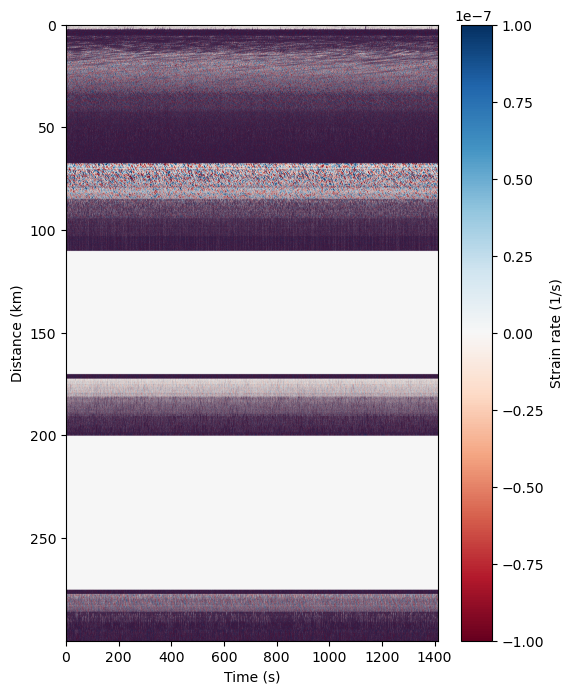

In [12]:
%matplotlib inline
plt.figure(figsize=(6,8))
vmin = -1e-7
vmax = 1e-7
plt.imshow(strainrate_data_array,aspect='auto', cmap='RdBu',extent = [times_seconds[0],times_seconds[-1],channel_loc_km[-1],channel_loc_km[0]],vmin=vmin,vmax=vmax)
plt.colorbar(label='Strain rate (1/s)')
plt.xlabel('Time (s)')
plt.ylabel('Distance (km)')

#### We can get channel locations by interpolating along the known cable route using repeater locations.

We have to "pin" some of our channels to known points in optical distance. We know that at each repeater, the overall amplitude of the signal will decrease sharply (due to lower noise). By looking at the median amplitude over time for all channels, we can pick the locations of the repeaters out in space, and then use these to estimate channel locations. Make sure to not confuse the locations of the repeaters with the locations of where the spatial mask starts (where we have filled in the data array with zeros).

Note that this will need to be redone whenever the channel spacing is changed!

Text(0, 0.5, 'Median amplitude across file time duration')

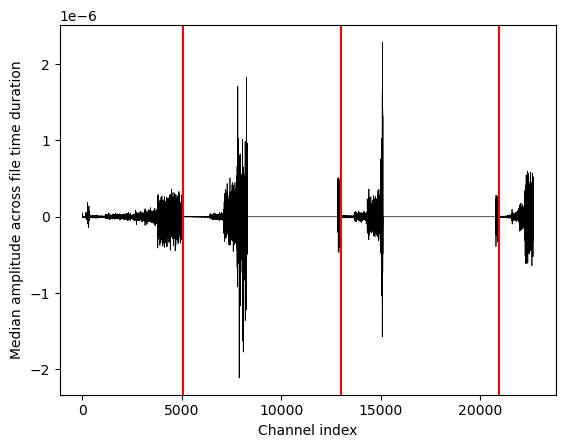

In [13]:
test_median = np.median(strainrate_data_array,axis=1)
np.shape(test_median)

# INDICES OF REPEATERS, PICKED BY EYE
rep1_index = 5084
rep2_index = 13014
rep3_index = 20939

fig,ax = plt.subplots(1)
ax.plot(test_median,'k-',linewidth=0.5)
ax.axvline(rep1_index,color='r')
ax.axvline(rep2_index,color='r')
ax.axvline(rep3_index,color='r')
ax.set_xlabel('Channel index')
ax.set_ylabel('Median amplitude across file time duration')

#### This example is for the north cable, but the south cable locations are available as well, and the process can be done the same way.

In [14]:
# Define repeater locations (these are also in a file in the Github)
repeater_lats = [45.14871,44.48169,44.35839,45.24241,45.48336,45.78700,45.79300,45.88690]
repeater_lons = [-125.11577,-125.44860,-124.99590,-124.75102,-125.94169,-127.15996,-128.36265,-129.61285]
north_repeater_lats = repeater_lats[3:]
north_repeater_lons = repeater_lons[3:]
south_repeater_lats = repeater_lats[:3]
south_repeater_lons = repeater_lons[:3]

# Read in cable locations
north = pd.read_csv('RSNcableroute_north_nostubs_withdepths.xy',delim_whitespace=True, header=None, names=['lat','lon','depth'],comment='>')
south = pd.read_csv('RSNcableroute_south_nostubs_withdepths.xy',delim_whitespace=True, header=None, names=['lat','lon','depth'],comment='>')

/tmp/ipykernel_12250/1381423895.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  north = pd.read_csv('RSNcableroute_north_nostubs_withdepths.xy',delim_whitespace=True, header=None, names=['lat','lon','depth'],comment='>')
/tmp/ipykernel_12250/1381423895.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  south = pd.read_csv('RSNcableroute_south_nostubs_withdepths.xy',delim_whitespace=True, header=None, names=['lat','lon','depth'],comment='>')


In [15]:
# We're using north cable here
cable = north

In [16]:
cable_lats = np.array(cable['lat']) 
cable_lons = np.array(cable['lon'])
cable_depths = np.array(cable['depth'])

# Calculate distance along the cable
geod = Geod(ellps="WGS84")
dists = [0.0]
for i in range(1, len(cable_lats)):
    _, _, dist = geod.inv(cable_lons[i-1], cable_lats[i-1], cable_lons[i], cable_lats[i])
    dists.append(dists[-1] + dist)
dists = np.array(dists)

# Interpolate lat and lon as functions of cable distance
lat_interp = scipy.interpolate.interp1d(dists, cable_lats, kind='linear')
lon_interp = scipy.interpolate.interp1d(dists, cable_lons, kind='linear')
depth_interp = scipy.interpolate.interp1d(dists, cable_depths, kind='linear')

# Use the pinning points of the three repeaters
repeater_cable_ind = [] 
for i in range(3):
    rep_dist = [geod.inv(north_repeater_lons[i],north_repeater_lats[i],lo,la)[-1] for lo,la in zip(cable_lons,cable_lats)]
    repeater_cable_ind.append(np.argmin(rep_dist))
pin_optical_dist = np.array(channel_loc)[[rep1_index,rep2_index,rep3_index]]
pin_cable_dist = dists[repeater_cable_ind]

# Solve for linear mapping along the cable:
A = np.vstack([pin_optical_dist, np.ones(len(pin_optical_dist))]).T
a, b = np.linalg.lstsq(A, pin_cable_dist, rcond=None)[0]

# Map optical distances to mapped real cable distances
mapped_distances = a * np.array(channel_loc) + b
# Clip values that are before the beach
mapped_distances = np.clip(mapped_distances, 0, dists[-1])

# Now interpolate the locations of the channels!
interp_lat = lat_interp(mapped_distances)
interp_lon = lon_interp(mapped_distances)
interp_depth = depth_interp(mapped_distances)


You can double check that it looks good by ensuring that the repeater locations defined in the DAS data match up well with the known map locations.

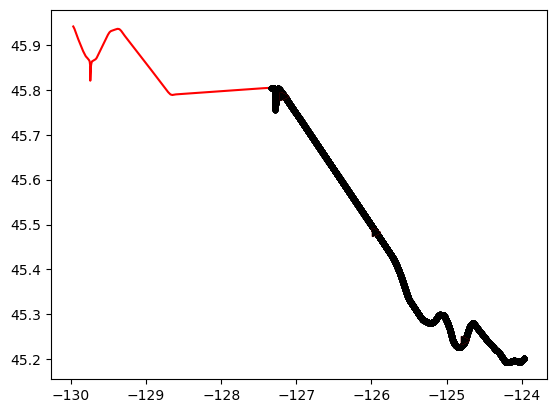

In [17]:
fig,ax = plt.subplots(1)
ax.plot(cable_lons,cable_lats,'r-')
ax.plot(interp_lon,interp_lat,'k.')

ax.plot(interp_lon[rep1_index],interp_lat[rep1_index],'r>')
ax.plot(north_repeater_lons[0],north_repeater_lats[0],'k>')

ax.plot(interp_lon[rep2_index],interp_lat[rep2_index],'r>')
ax.plot(north_repeater_lons[1],north_repeater_lats[1],'k>')

ax.plot(interp_lon[rep3_index],interp_lat[rep3_index],'r>')
ax.plot(north_repeater_lons[2],north_repeater_lats[2],'k>')